In [15]:
#Synthetic HTE with S/T/X-learners, Qini, calibration, and subgroup rules

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier, export_text
import shap
import matplotlib.pyplot as plt



In [17]:
#1.Generate synthetic dataset
np.random.seed(42)
n = 5000

age = np.random.normal(35, 10, n).clip(18, 70)
prior_spend = np.random.exponential(300, n)
engagement = np.random.beta(2, 5, n)
campaign_history = np.random.binomial(1, 0.3, n)

X = pd.DataFrame({
    'age': age,
    'priorspend': prior_spend,
    'engagement': engagement,
    'campaignhistory': campaign_history
})

def true_uplift(x):
    return (
        0.2 * (x['engagement'] > 0.6).astype(float)
        + 0.1 * (x['priorspend'] > 500).astype(float)
        - 0.05 * (x['age'] > 50).astype(float)
    )

#Treatment assignment depends on features (to create confounding risk)
propensity = 0.3 + 0.2 * X['engagement'] - 0.1 * X['campaignhistory']
propensity = np.clip(propensity, 0.05, 0.95)
T = np.random.binomial(1, propensity)

#Outcome model with treatment effect
baseoutcome = 0.1 + 0.3 * X['engagement'] + 0.001 * X['priorspend']
tau = true_uplift(X)
Yprob = baseoutcome + T * tau
Y = np.random.binomial(1, np.clip(Yprob, 0, 1))

data = X.copy()
data['T'] = T
data['Y'] = Y

#Optional: Preview
print("Dataset head:")
print(data.head())

Dataset head:
         age  priorspend  engagement  campaignhistory  T  Y
0  39.967142   55.262169    0.168286                0  0  0
1  33.617357   63.192141    0.126683                0  0  0
2  41.476885  185.251754    0.348115                0  0  1
3  50.230299  101.179307    0.325335                0  0  0
4  32.658466   85.291527    0.565656                0  0  0


In [19]:
#2. Propensity scores
features = ['age', 'priorspend', 'engagement', 'campaignhistory']
X_cov = data[features]
propmodel = CalibratedClassifierCV(LogisticRegression(max_iter=2000))
propmodel.fit(X_cov, data['T'])
ehat = propmodel.predict_proba(X_cov)[:, 1]

In [21]:
#3. Train/test split
Xtrain, Xtest, ytrain, ytest, ttrain, ttest = train_test_split(
    X_cov, data['Y'], data['T'], test_size=0.3, random_state=42, stratify=data['T']
)

In [23]:
#4. S-learner
sdata = Xtrain.copy()
sdata['T'] = ttrain
smodel = GradientBoostingRegressor(random_state=42)
smodel.fit(sdata, ytrain)
spred1 = smodel.predict(Xtest.assign(T=1))
spred0 = smodel.predict(Xtest.assign(T=0))
cates = spred1 - spred0

In [25]:
#5. T-learner
tmodel1 = GradientBoostingRegressor(random_state=42).fit(Xtrain[ttrain == 1], ytrain[ttrain == 1])
tmodel0 = GradientBoostingRegressor(random_state=42).fit(Xtrain[ttrain == 0], ytrain[ttrain == 0])
catet = tmodel1.predict(Xtest) - tmodel0.predict(Xtest)

In [27]:
#6. X-learner
X1 = Xtrain[ttrain == 1]; y1 = ytrain[ttrain == 1]
X0 = Xtrain[ttrain == 0]; y0 = ytrain[ttrain == 0]

mu0ontreated = tmodel0.predict(X1)
mu1oncontrol = tmodel1.predict(X0)

D1 = y1.values - mu0ontreated              # imputed ITE for treated
D0 = mu1oncontrol - y0.values              # imputed ITE for control

xmodel1 = GradientBoostingRegressor(random_state=42).fit(X1, D1)
xmodel0 = GradientBoostingRegressor(random_state=42).fit(X0, D0)
w = propmodel.predict_proba(Xtest)[:, 1]    # weights from propensity
catex = w * xmodel0.predict(Xtest) + (1 - w) * xmodel1.predict(Xtest)

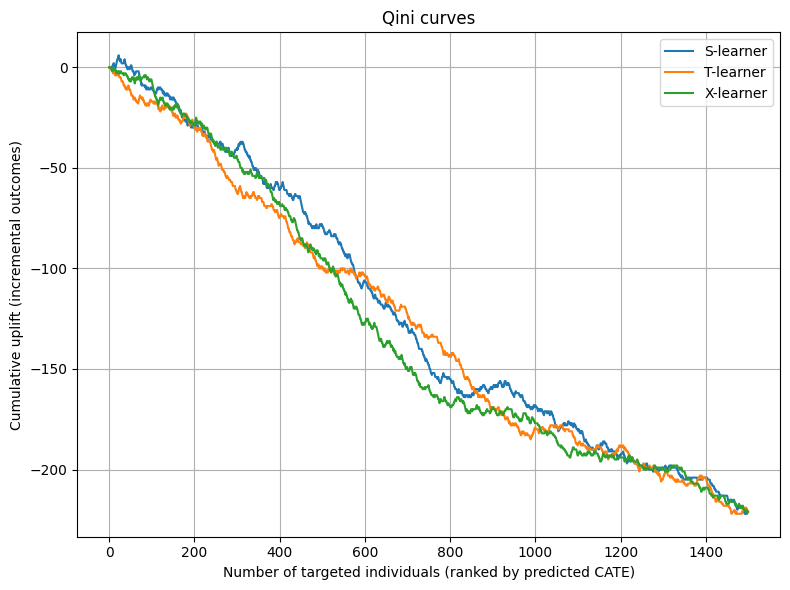

In [29]:
#7. Qini curves and policy value
def qinicurve(ytrue, t, cate_pred):
    df = pd.DataFrame({'y': ytrue, 't': t, 'cate': cate_pred})
    df = df.sort_values('cate', ascending=False).reset_index(drop=True)
    # Incremental outcome: treated - control along the ranking
    cumytreated = np.cumsum(df['y'] * df['t'])
    cumycontrol = np.cumsum(df['y'] * (1 - df['t']))
    uplift = cumytreated - cumycontrol
    return uplift

uplifts = qinicurve(ytest, ttest, cates)
upliftt = qinicurve(ytest, ttest, catet)
upliftx = qinicurve(ytest, ttest, catex)

plt.figure(figsize=(8, 6))
plt.plot(uplifts, label='S-learner')
plt.plot(upliftt, label='T-learner')
plt.plot(upliftx, label='X-learner')
plt.xlabel("Number of targeted individuals (ranked by predicted CATE)")
plt.ylabel("Cumulative uplift (incremental outcomes)")
plt.title("Qini curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
#Policy value at top-k (example: top 20%)
k = int(0.2 * len(Xtest))
order = np.argsort(-catex)
treatedpolicy = ttest.iloc[order[:k]]
outcomespolicy = ytest.iloc[order[:k]]
policyvalue = outcomespolicy[treatedpolicy == 1].sum() - outcomespolicy[treatedpolicy == 0].sum()
print(f"Policy value (top 20% by X-learner CATE): {policyvalue}")

Policy value (top 20% by X-learner CATE): -44


/tmp/ipython-input-725364512.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibplot = calibdf.groupby('bin')['uplift'].mean()


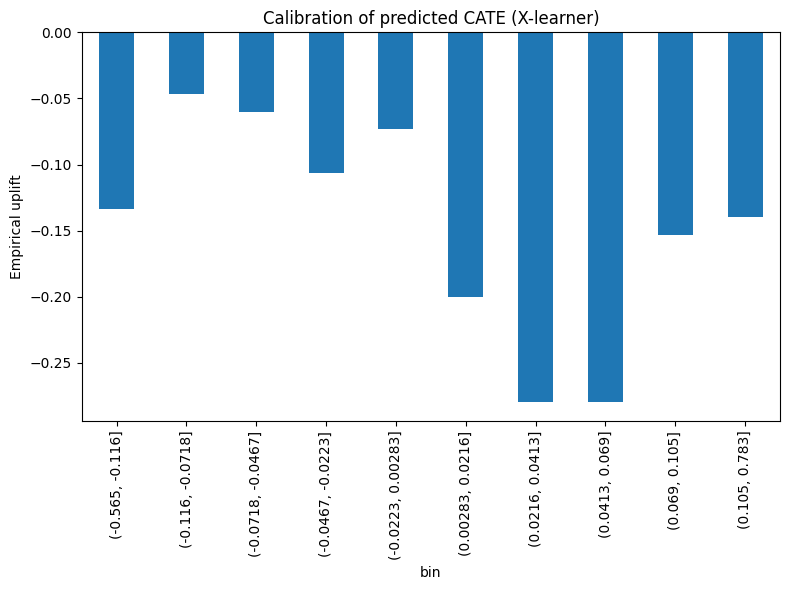

In [33]:
#8. Calibration of uplift (bin predicted CATE and compare empirical uplift)
bins = pd.qcut(catex, q=10, duplicates='drop')
calibdf = pd.DataFrame({'bin': bins, 'cate': catex, 'y': ytest, 't': ttest})
calibdf['uplift'] = calibdf['y'] * calibdf['t'] - calibdf['y'] * (1 - calibdf['t'])
calibplot = calibdf.groupby('bin')['uplift'].mean()


plt.figure(figsize=(8, 6))
calibplot.plot(kind='bar')
plt.ylabel("Empirical uplift")
plt.title("Calibration of predicted CATE (X-learner)")
plt.tight_layout()
plt.show()

In [35]:
#9. Identify high-value subgroups via interpretable rules
threshold = np.percentile(catex, 80)
ishigh = (catex >= threshold).astype(int)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(Xtest, ishigh)
print("Subgroup rules for high uplift (top 20%):")
print(export_text(tree, feature_names=features))

Subgroup rules for high uplift (top 20%):
|--- age <= 39.89
|   |--- engagement <= 0.60
|   |   |--- priorspend <= 379.35
|   |   |   |--- class: 0
|   |   |--- priorspend >  379.35
|   |   |   |--- class: 0
|   |--- engagement >  0.60
|   |   |--- age <= 29.54
|   |   |   |--- class: 0
|   |   |--- age >  29.54
|   |   |   |--- class: 1
|--- age >  39.89
|   |--- priorspend <= 198.87
|   |   |--- age <= 58.82
|   |   |   |--- class: 0
|   |   |--- age >  58.82
|   |   |   |--- class: 1
|   |--- priorspend >  198.87
|   |   |--- age <= 51.84
|   |   |   |--- class: 1
|   |   |--- age >  51.84
|   |   |   |--- class: 0



/tmp/ipython-input-1066845601.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, Xtest)


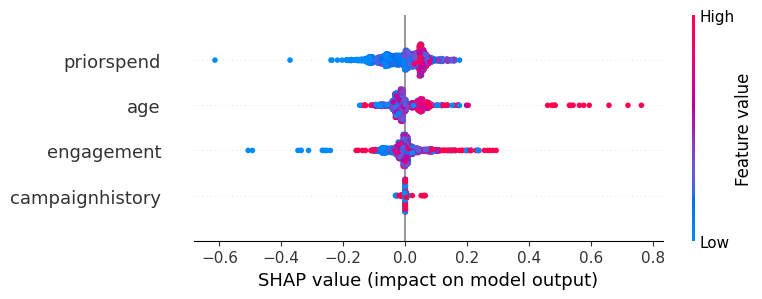

In [38]:
#10. SHAP for interpreting uplift drivers (X-learner component)

# Use one of the X-learner components (xmodel1) for local/global explanations
explainer = shap.Explainer(xmodel1, Xtest)
shap_values = explainer(Xtest)
shap.summary_plot(shap_values, Xtest)